# 다층 퍼셉트론으로 클래스 모델 구성 및 하이퍼파라미터 최적화

- 목차
1. 라이브러리 import
2. 데이터 준비
    - trian/valid/test 데이터 분리
    - 데이터 표준화
    - Tensor 형태로 데이터 변환
3. 미니배치 준비
4. 모델 준비
5. 학습 및 평가 함수 (+ Early Stopping)
6. Optuna 활용해 하이퍼파라미터 최적화
7. 최적 파라미터로 재학습
8. 시각화

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import optuna

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

c:\Users\playdata2\DL\dl_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

print(X.shape, y.shape)

(569, 30) (569,)


In [3]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
)

print(X_train.shape, X_val.shape, y_train.shape, y_test.shape)

(341, 30) (114, 30) (341,) (114,)


In [5]:
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [7]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

print(X_train_t.shape, X_val_t.shape, X_test_t.shape)
print(y_train_t.shape, y_val_t.shape, y_test_t.shape)

torch.Size([341, 30]) torch.Size([114, 30]) torch.Size([114, 30])
torch.Size([341, 1]) torch.Size([114, 1]) torch.Size([114, 1])


In [8]:
def make_loaders(batch_size=64):
    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(X_val_t, y_val_t),
        batch_size=batch_size,
        shuffle=False
    )
    test_loader = DataLoader(
        TensorDataset(X_test_t, y_test_t),
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader

In [9]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1=64, hidden_dim2=32, dropout_p=0.0):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc_out = nn.Linear(hidden_dim2, 1)

        self.act = nn.ReLU()
        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.dropout(x)

        x = self.act(self.fc2(x))
        x = self.dropout(x)

        x = self.fc_out(x)

        return x

In [10]:
criterion = nn.BCEWithLogitsLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    losses = []

    for xb, yb in loader:
        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))

In [11]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    losses = []
    y_true_all = []
    y_prob_all = []

    for xb, yb in loader:
        logits = model(xb)
        loss = criterion(logits, yb)
        prob = torch.sigmoid(logits)

        losses.append(loss.item())
        y_true_all.append(yb.cpu().numpy())
        y_prob_all.append(prob.cpu().numpy())

    y_true = np.vstack(y_true_all).ravel()
    y_prob = np.vstack(y_prob_all).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    return float(np.mean(losses)), acc, auc, y_true, y_prob

In [12]:
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float('inf')
        self.counter = 0
        self.stop = False

    def step(self, val_loss):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

In [17]:
def fit(model, train_loader, val_loader, lr=1e-3, n_epochs=200, weight_decay=0.0):
    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    hist = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
    best_val = np.inf
    best_state = None

    early = EarlyStopping(patience=20)

    for epoch in range(1, n_epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc, va_auc, _, _ = evaluate(model, val_loader)

        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(va_loss)
        hist['val_acc'].append(va_acc)
        hist['val_auc'].append(va_auc)

        if va_loss < best_val:
            best_val = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        early.step(va_loss)
        if early.stop:
            print(f'Epoch {epoch}에서 종료됨')
            break
    if best_state is not None:
        model.load_state_dict(best_state)

    return hist

In [18]:
def objective(trial):
    hidden_dim1 = trial.suggest_categorical('hidden_dim1', [32, 64, 128, 256])
    hidden_dim2 = trial.suggest_categorical('hidden_dim2', [16, 32, 64, 128])
    dropout_p = trial.suggest_float('dropout_p', 0.0, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    train_loader, val_loader, _ = make_loaders(batch_size=batch_size)

    model = MLP(
        input_dim=X_train.shape[-1],
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2,
        dropout_p=dropout_p
    )

    hist = fit(
        model, train_loader, val_loader,
        lr=lr,
        n_epochs=150,
        weight_decay=weight_decay
    )

    best_val_auc = float(np.max(hist['val_auc']))

    return best_val_auc

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(f'옵튜나 최고 성능 조합: {study.best_params}')
print(f'옵튜나 최고 성능 val_auc: {study.best_value}')

[I 2026-07-28 09:32:04,847] A new study created in memory with name: no-name-b517dad5-ef39-4b57-9959-be6a7c838abb
[I 2026-07-28 09:32:05,480] Trial 0 finished with value: 0.9983622666229938 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 16, 'dropout_p': 0.3146412365944708, 'lr': 0.008969330465122863, 'weight_decay': 0.00012443819574185774, 'batch_size': 32}. Best is trial 0 with value: 0.9983622666229938.


Epoch 25에서 종료됨


[I 2026-07-28 09:32:05,974] Trial 1 finished with value: 0.9977071732721913 and parameters: {'hidden_dim1': 64, 'hidden_dim2': 16, 'dropout_p': 0.04930402560212055, 'lr': 0.006184467573109399, 'weight_decay': 2.198977524277223e-06, 'batch_size': 64}. Best is trial 0 with value: 0.9983622666229938.


Epoch 33에서 종료됨


[I 2026-07-28 09:32:07,158] Trial 2 finished with value: 0.9980347199475925 and parameters: {'hidden_dim1': 32, 'hidden_dim2': 32, 'dropout_p': 0.3848945163568615, 'lr': 0.007339783229254252, 'weight_decay': 0.0005373670584984553, 'batch_size': 32}. Best is trial 0 with value: 0.9983622666229938.


...

Epoch 33에서 종료됨


[I 2026-07-28 09:32:31,074] Trial 18 finished with value: 0.9980347199475925 and parameters: {'hidden_dim1': 32, 'hidden_dim2': 128, 'dropout_p': 0.21291093473925593, 'lr': 0.0007324500741853157, 'weight_decay': 1.0543738804043092e-05, 'batch_size': 64}. Best is trial 0 with value: 0.9983622666229938.


Epoch 146에서 종료됨


[I 2026-07-28 09:32:32,856] Trial 19 finished with value: 0.9967245332459875 and parameters: {'hidden_dim1': 128, 'hidden_dim2': 16, 'dropout_p': 0.4152349103512442, 'lr': 0.00021214100092997902, 'weight_decay': 1.007999645726575e-06, 'batch_size': 128}. Best is trial 0 with value: 0.9983622666229938.


옵튜나 최고 성능 조합: {'hidden_dim1': 256, 'hidden_dim2': 16, 'dropout_p': 0.3146412365944708, 'lr': 0.008969330465122863, 'weight_decay': 0.00012443819574185774, 'batch_size': 32}
옵튜나 최고 성능 val_auc: 0.9983622666229938


In [20]:
best = study.best_params

train_loader, val_loader, test_loader = make_loaders(batch_size=best['batch_size'])

best_model = MLP(
    input_dim=X_train.shape[-1],
    hidden_dim1=best['hidden_dim1'],
    hidden_dim2=best['hidden_dim2'],
    dropout_p=best['dropout_p']
)

history = fit(
    best_model,
    train_loader, val_loader,
    lr=best['lr'],
    n_epochs=1000,
    weight_decay=best['weight_decay']
)

test_loss, test_acc, test_auc, y_true, y_prob = evaluate(best_model, test_loader)

print(f'Test best acc: {test_acc:.4f}, loss: {test_loss:.4f}, auc: {test_auc:.4f}')

Epoch 36에서 종료됨
Test best acc: 0.9561, loss: 0.1377, auc: 0.9891


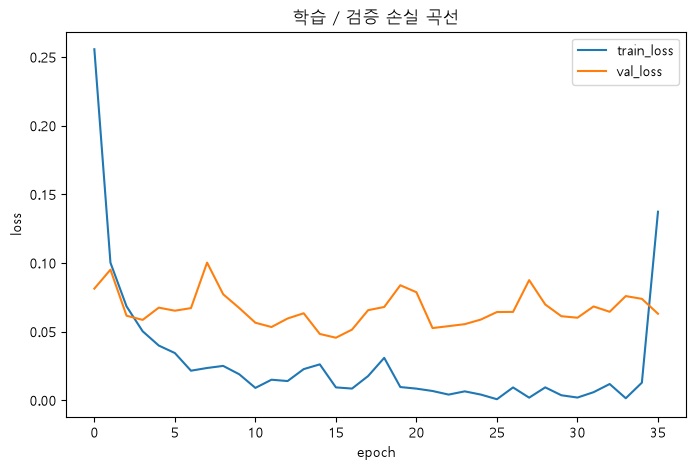

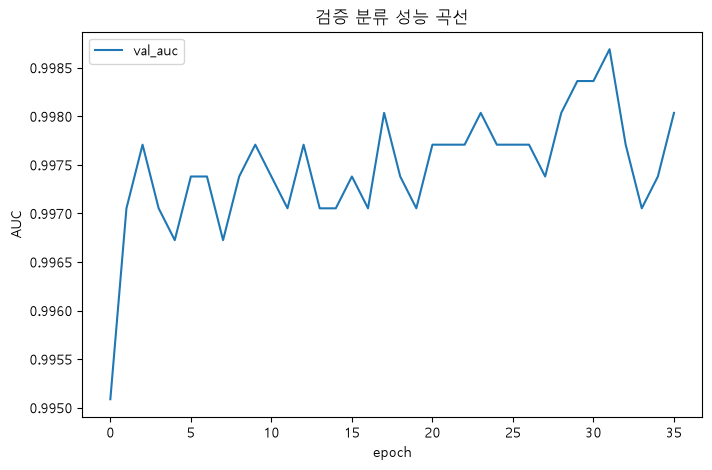

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('학습 / 검증 손실 곡선')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history['val_auc'], label='val_auc')
plt.xlabel('epoch')
plt.ylabel('AUC')
plt.title('검증 분류 성능 곡선')
plt.legend()
plt.show()

손실 곡선: 학습 손실 줄어드는데 검증 손실 줄어들지 않으면 과적합 신호

AUC 곡선: 모델 전반적 분류 능력 변화 확인  
AUC 꾸준히 상승하면 클래스 간 구분 능력 향상 중

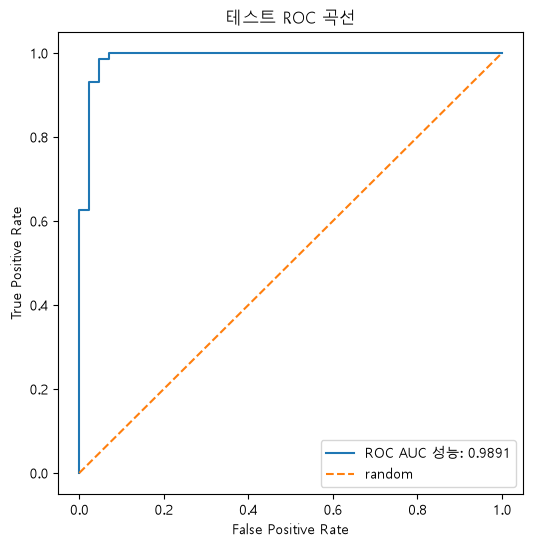

In [22]:
fpr, tpr, thr = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC AUC 성능: {test_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('테스트 ROC 곡선')
plt.legend()
plt.show()

ROC 곡선은 모델이 양성과 음성을 얼마나 잘 구분하는지 확인 가능한 지표  
AUC는 ROC 곡선 아래 면적으로, 무작위로 하나의 양성과 음성을 선택했을 때 모델이 올바르게 순서 매길 확률

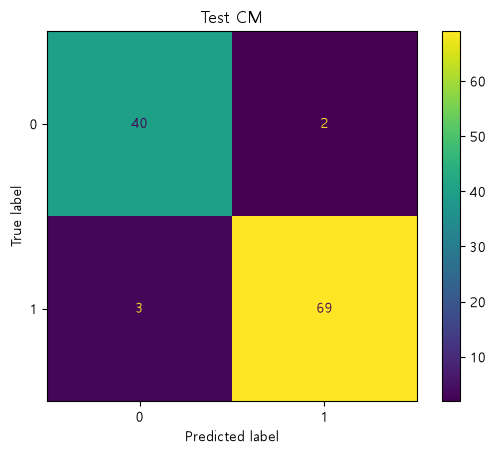

In [27]:
y_pred = (y_prob > 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Test CM')
plt.show()

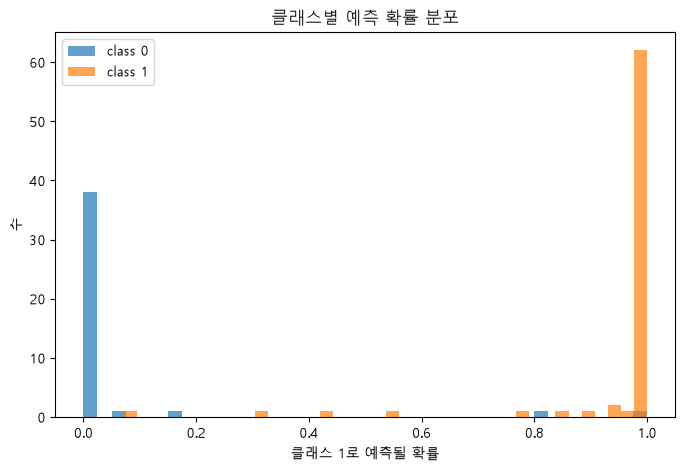

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(
    y_prob[y_true == 0],
    bins=40,
    alpha=0.7,
    label='class 0'
)

plt.hist(
    y_prob[y_true == 1],
    bins=40,
    alpha=0.7,
    label='class 1'
)

plt.xlabel('클래스 1로 예측될 확률')
plt.ylabel('수')
plt.title('클래스별 예측 확률 분포')
plt.legend()
plt.show()

두 클래스 겹치는 부분 약간 존재하나 크지 않음  
분류 경계 명확한 편, 모델 확신 높음